In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import VarianceThreshold

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [2]:
fd1 = pd.read_csv("data/train_FD001.txt", sep=" ", header=None).dropna(axis=1)
fd2 = pd.read_csv("data/train_FD002.txt", sep=" ", header=None).dropna(axis=1)
fd3 = pd.read_csv("data/train_FD003.txt", sep=" ", header=None).dropna(axis=1)
fd4 = pd.read_csv("data/train_FD004.txt", sep=" ", header=None).dropna(axis=1)

In [3]:
columns = ["unit","cycle","op_setting_1","op_setting_2","op_setting_3"]

for i in range(1,22):
    columns.append(f"sensor_{i}")

for df in [fd1,fd2,fd3,fd4]:
    df.columns = columns

In [4]:
fd1["dataset"] = "FD001"
fd2["dataset"] = "FD002"
fd3["dataset"] = "FD003"
fd4["dataset"] = "FD004"

In [5]:
df = pd.concat([fd1,fd2,fd3,fd4], ignore_index=True)

print("Merged Dataset Shape:", df.shape)
df.head()

Merged Dataset Shape: (160359, 27)


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001


In [6]:
df["unit_id"] = df["dataset"] + "_" + df["unit"].astype(str)

In [7]:
max_cycle = df.groupby("unit_id")["cycle"].max().reset_index()
max_cycle.columns = ["unit_id","max_cycle"]

df = df.merge(max_cycle, on="unit_id")

df["RUL"] = df["max_cycle"] - df["cycle"]

df.drop(columns=["max_cycle"], inplace=True)

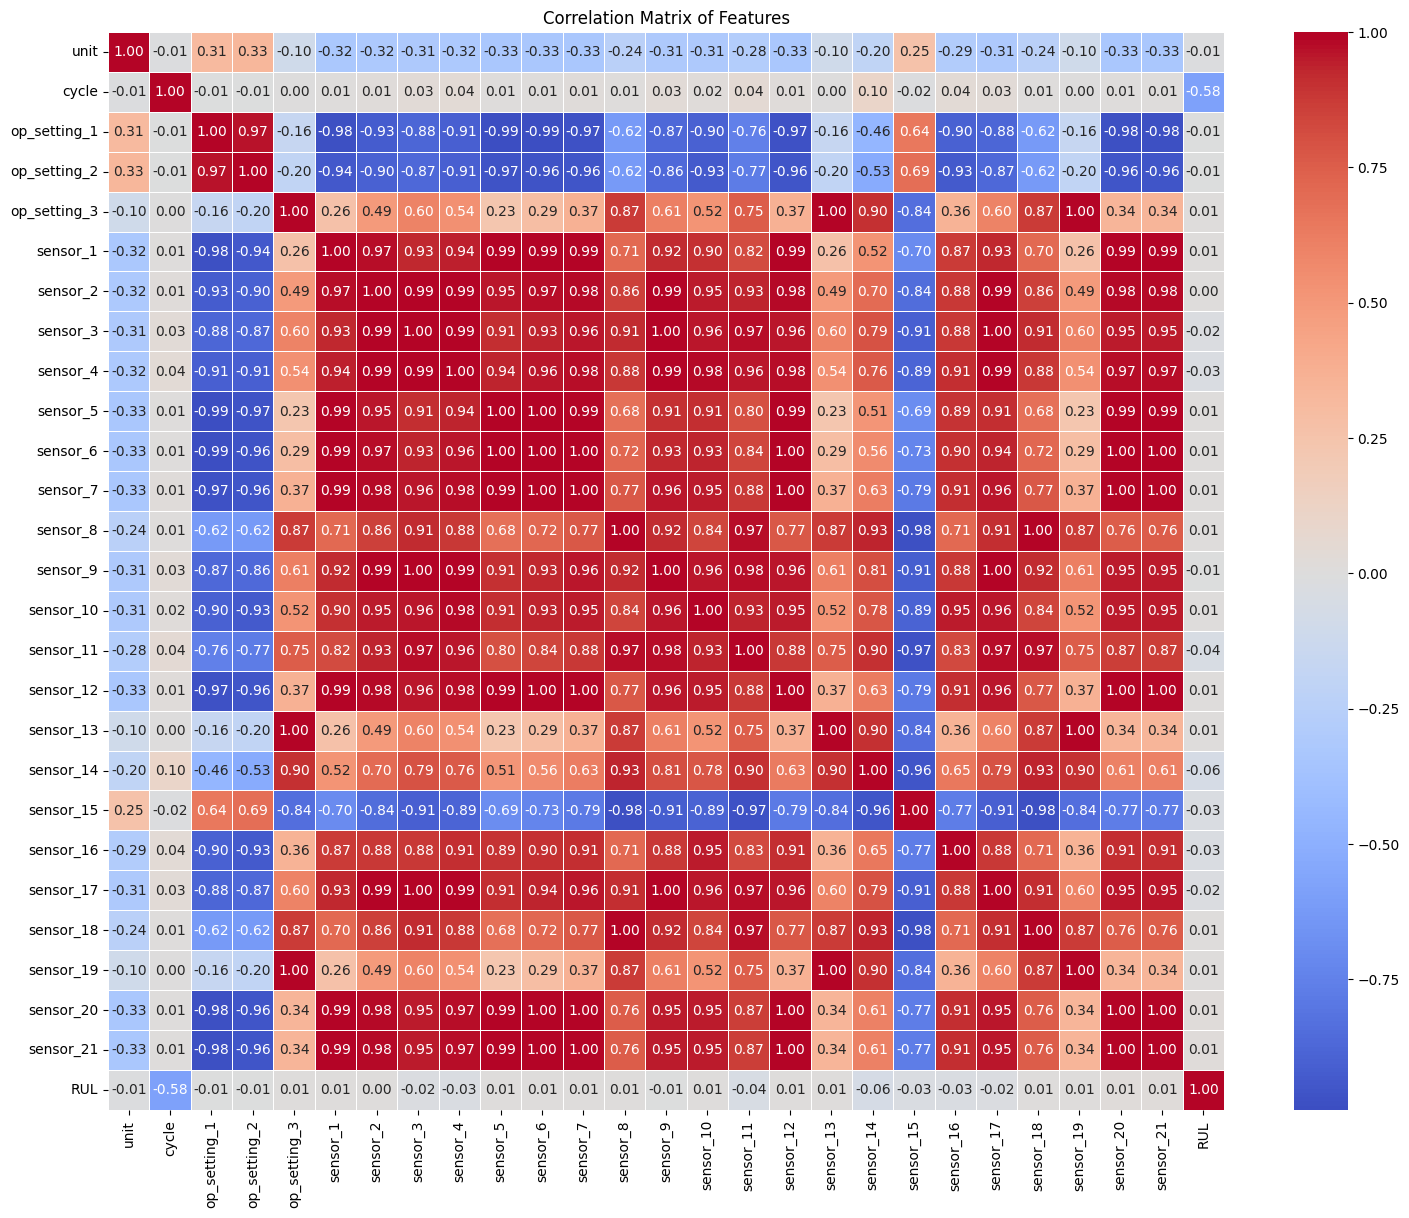

In [8]:
corr_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Features")
plt.show()

In [9]:
features = df.drop(columns=["dataset","unit_id","RUL"])

selector = VarianceThreshold(threshold=1e-2)
selector.fit(features)

selected_columns = features.columns[selector.get_support()]

df = df[selected_columns.tolist() + ["dataset","unit_id","RUL"]]

print("Remaining Features:", len(selected_columns))

Remaining Features: 25


In [10]:
engine_ids = df["unit_id"].unique()
rng = np.random.default_rng(42)
engine_ids = rng.permutation(engine_ids)

split = int(len(engine_ids) * 0.8)

train_engines = engine_ids[:split]
val_engines = engine_ids[split:]

train_df = df[df["unit_id"].isin(train_engines)].copy()
val_df = df[df["unit_id"].isin(val_engines)].copy()

In [11]:
feature_cols = train_df.drop(columns=["dataset","unit_id","RUL"]).columns

scaler = MinMaxScaler()

train_df[feature_cols] = train_df[feature_cols].astype(float)
val_df[feature_cols] = val_df[feature_cols].astype(float)

train_df.loc[:, feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df.loc[:, feature_cols] = scaler.transform(val_df[feature_cols])

In [12]:
MAX_RUL = 125

train_df["RUL"] = train_df["RUL"].clip(upper=MAX_RUL) / MAX_RUL
val_df["RUL"] = val_df["RUL"].clip(upper=MAX_RUL) / MAX_RUL

print("RUL range after normalization:")
print(f"  Train: {train_df['RUL'].min():.4f} – {train_df['RUL'].max():.4f}")
print(f"  Val  : {val_df['RUL'].min():.4f} – {val_df['RUL'].max():.4f}")

RUL range after normalization:
  Train: 0.0000 – 1.0000
  Val  : 0.0000 – 1.0000


In [13]:
window_size = 30
sequence_stride = 2

def create_sequences(data):

    X, y = [], []

    for uid in data["unit_id"].unique():

        engine = data[data["unit_id"] == uid]

        # Include the last valid window and use the last timestep label in each window.
        for i in range(0, len(engine) - window_size + 1, sequence_stride):

            X.append(
                engine[feature_cols]
                .iloc[i:i+window_size]
                .values
            )

            y.append(
                engine["RUL"].iloc[i+window_size-1]
            )

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [14]:
X_train, y_train = create_sequences(train_df)
X_val, y_val = create_sequences(val_df)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print(f"Window size: {window_size}, stride: {sequence_stride}")

Train Shape: (56377, 30, 25)
Validation Shape: (13694, 30, 25)
Window size: 30, stride: 2


In [15]:
optimizer = Adam(learning_rate=0.0005)

lstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(256, return_sequences=True, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),

    LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),

    LSTM(96, return_sequences=True, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(48, return_sequences=True, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(32, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
    Dense(1)
])

lstm_model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

import io
buf = io.StringIO()
lstm_model.summary(print_fn=lambda x: buf.write(x + "\n"))
print(buf.getvalue())

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 256)        │       288,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)     

In [16]:
def make_reduce_lr():
    return ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[make_reduce_lr()]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 173s 694ms/step - loss: 0.2621 - mae: 0.3220 - val_loss: 0.2059 - val_mae: 0.2928 - learning_rate: 5.0000e-04
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 144s 651ms/step - loss: 0.1667 - mae: 0.2170 - val_loss: 0.1595 - val_mae: 0.2279 - learning_rate: 5.0000e-04
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 170s 770ms/step - loss: 0.1431 - mae: 0.1844 - val_loss: 0.1417 - val_mae: 0.2012 - learning_rate: 5.0000e-04
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 176s 796ms/step - loss: 0.1289 - mae: 0.1664 - val_loss: 0.2988 - val_mae: 0.3976 - learning_rate: 5.0000e-04
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 135s 609ms/step - loss: 0.1196 - mae: 0.1578 - val_loss: 0.1266 - val_mae: 0.1866 - learning_rate: 5.0000e-04
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 100s 451ms/step - loss: 0.1110 - mae: 0.1516 - val_loss: 0.1217 - val_mae: 0.1944 - learning_rate: 5.0000e-04
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 107s 483ms/step - loss: 0.1026 - mae: 0.1449 - val_loss: 0.1

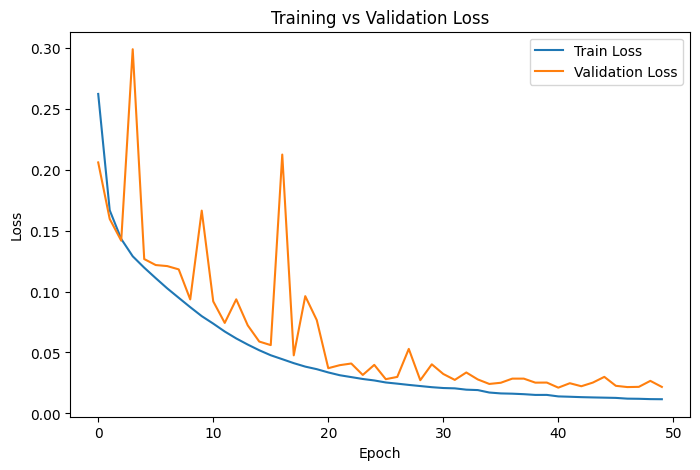

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm.history["loss"],label="Train Loss")
plt.plot(history_lstm.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [18]:
optimizer_gru = Adam(learning_rate=0.0005)

gru_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    GRU(256, return_sequences=True, kernel_regularizer=l2(1e-4)),
    Dropout(0.4),

    GRU(128, return_sequences=True, kernel_regularizer=l2(1e-4)),
    Dropout(0.4),

    GRU(96, return_sequences=True, kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    GRU(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    GRU(32, return_sequences=True, kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    GRU(16, kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(
    optimizer=optimizer_gru,
    loss="mse",
    metrics=["mae"]
)

buf = io.StringIO()
gru_model.summary(print_fn=lambda x: buf.write(x + "\n"))
print(buf.getvalue())

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 256)        │       217,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 128)        │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 30, 96)         │        65,088 │
├─────────────────────────────────┼───────────────────

In [19]:
history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[make_reduce_lr()]
 )

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 97s 393ms/step - loss: 0.1906 - mae: 0.3018 - val_loss: 0.1008 - val_mae: 0.1997 - learning_rate: 5.0000e-04
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 81s 365ms/step - loss: 0.1037 - mae: 0.2144 - val_loss: 0.0667 - val_mae: 0.1579 - learning_rate: 5.0000e-04
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 90s 408ms/step - loss: 0.0814 - mae: 0.1885 - val_loss: 0.0588 - val_mae: 0.1465 - learning_rate: 5.0000e-04
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 79s 355ms/step - loss: 0.0724 - mae: 0.1783 - val_loss: 0.0578 - val_mae: 0.1560 - learning_rate: 5.0000e-04
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 67s 304ms/step - loss: 0.0652 - mae: 0.1690 - val_loss: 0.0538 - val_mae: 0.1432 - learning_rate: 5.0000e-04
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 65s 295ms/step - loss: 0.0591 - mae: 0.1602 - val_loss: 0.0469 - val_mae: 0.1293 - learning_rate: 5.0000e-04
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 64s 291ms/step - loss: 0.0548 - mae: 0.1544 - val_loss: 0.0448 - v

In [20]:
y_pred_lstm = lstm_model.predict(X_val).flatten()
y_pred_gru  = gru_model.predict(X_val).flatten()

# Scale back to original RUL range for interpretable metrics
y_val_orig       = y_val        * MAX_RUL
y_pred_lstm_orig = y_pred_lstm  * MAX_RUL
y_pred_gru_orig  = y_pred_gru   * MAX_RUL

# ── LSTM metrics ──────────────────────────────────────────────
rmse_lstm = np.sqrt(mean_squared_error(y_val_orig, y_pred_lstm_orig))
mae_lstm  = mean_absolute_error(y_val_orig, y_pred_lstm_orig)
r2_lstm   = r2_score(y_val_orig, y_pred_lstm_orig)

# ── GRU metrics ───────────────────────────────────────────────
rmse_gru = np.sqrt(mean_squared_error(y_val_orig, y_pred_gru_orig))
mae_gru  = mean_absolute_error(y_val_orig, y_pred_gru_orig)
r2_gru   = r2_score(y_val_orig, y_pred_gru_orig)

print(f"{'Metric':<10} {'LSTM':>10} {'GRU':>10}")
print("-" * 32)
print(f"{'RMSE':<10} {rmse_lstm:>10.4f} {rmse_gru:>10.4f}")
print(f"{'MAE':<10} {mae_lstm:>10.4f} {mae_gru:>10.4f}")
print(f"{'R²':<10} {r2_lstm:>10.4f} {r2_gru:>10.4f}")

428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step
428/428 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step
Metric           LSTM        GRU
--------------------------------
RMSE          17.0281    16.2063
MAE           12.8451    12.1022
R²             0.8343     0.8499


In [21]:
better = "LSTM" if rmse_lstm < rmse_gru else "GRU"
print(f"{better} performs better overall")
print(f"  RMSE  → LSTM: {rmse_lstm:.4f}  |  GRU: {rmse_gru:.4f}")
print(f"  MAE   → LSTM: {mae_lstm:.4f}  |  GRU: {mae_gru:.4f}")
print(f"  R²    → LSTM: {r2_lstm:.4f}  |  GRU: {r2_gru:.4f}")

GRU performs better overall
  RMSE  → LSTM: 17.0281  |  GRU: 16.2063
  MAE   → LSTM: 12.8451  |  GRU: 12.1022
  R²    → LSTM: 0.8343  |  GRU: 0.8499


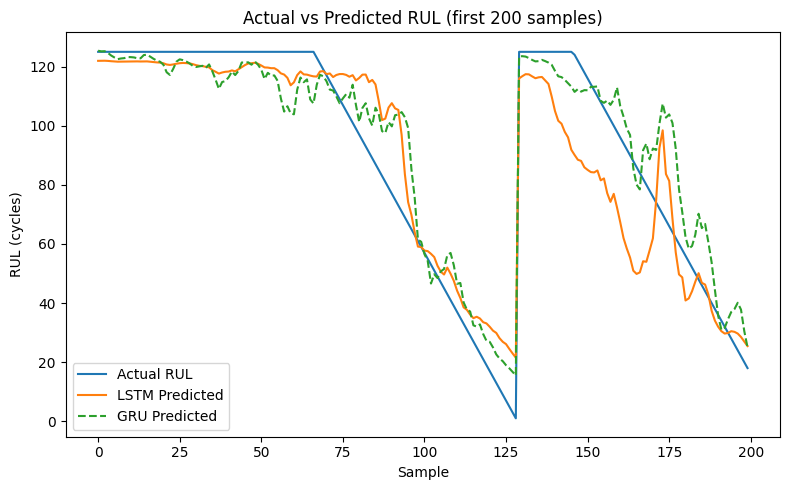

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(y_val_orig[:200],        label="Actual RUL")
plt.plot(y_pred_lstm_orig[:200],  label="LSTM Predicted")
plt.plot(y_pred_gru_orig[:200],   label="GRU Predicted", linestyle="--")

plt.title("Actual vs Predicted RUL (first 200 samples)")
plt.xlabel("Sample")
plt.ylabel("RUL (cycles)")
plt.legend()
plt.tight_layout()
plt.show()